In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [2]:
data = pd.read_csv('datasets/facebook_live_sellers.csv')
print(f"Data shape: {data.shape}, data size: {data.size}")

Data shape: (7050, 12), data size: 84600


In [ ]:
data.head()

In [ ]:
data.info()

In [ ]:
data.isna().sum()

In [ ]:
data.describe()

In [3]:
features = data[['num_reactions', 'num_comments', 'num_shares', 'num_likes',
                 'num_loves', 'num_wows', 'num_hahas', 'num_sads', 'num_angrys']]
print(f"Feature size: {features.shape}")
print(f"Data size: {data.shape}")

Feature size: (7050, 9)
Data size: (7050, 12)


In [5]:
features.describe()

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000
mean,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191
std,462.625309,889.636820,131.599965,449.472357,39.972930,8.719650,3.957183,1.597156,0.726812
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000
max,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000


In [72]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
df_scaled_features = pd.DataFrame(scaled_features, columns=features.columns)

In [73]:
df_scaled_features.describe()

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
count,7050.000000,7050.000000,7050.000000,7.050000e+03,7050.000000,7.050000e+03,7.050000e+03,7.050000e+03,7.050000e+03
mean,0.000000,0.000000,0.000000,1.612579e-17,0.000000,8.062896e-18,-1.612579e-17,-8.062896e-18,1.612579e-17
std,1.000071,1.000071,1.000071,1.000071e+00,1.000071,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-0.497451,-0.252206,-0.304144,-4.784685e-01,-0.318454,-1.478790e-01,-1.760099e-01,-1.525870e-01,-1.557480e-01
25%,-0.460702,-0.252206,-0.304144,-4.406437e-01,-0.318454,-1.478790e-01,-1.760099e-01,-1.525870e-01,-1.557480e-01
50%,-0.368828,-0.247710,-0.304144,-3.494192e-01,-0.318454,-1.478790e-01,-1.760099e-01,-1.525870e-01,-1.557480e-01
75%,-0.024032,-0.226351,-0.273747,-6.740185e-02,-0.243398,-1.478790e-01,-1.760099e-01,-1.525870e-01,-1.557480e-01
max,9.684296,23.343365,25.715945,1.000123e+01,16.118835,3.173639e+01,3.950149e+01,3.178144e+01,4.249930e+01


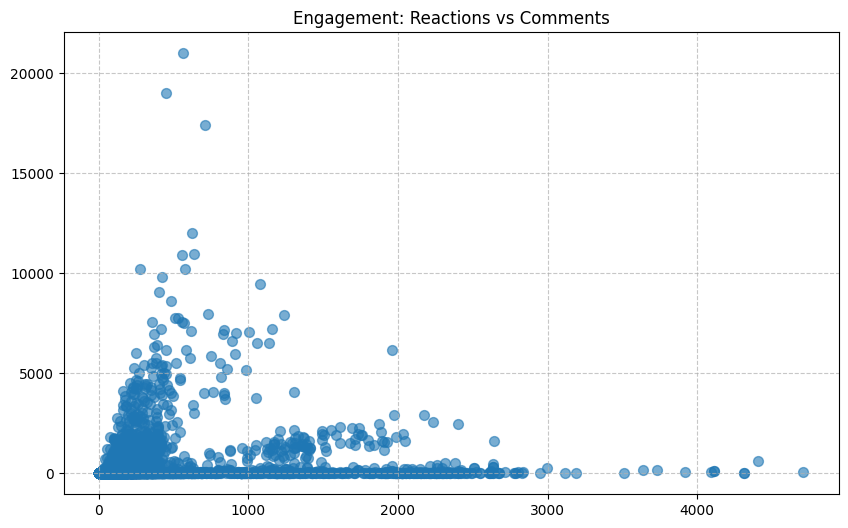

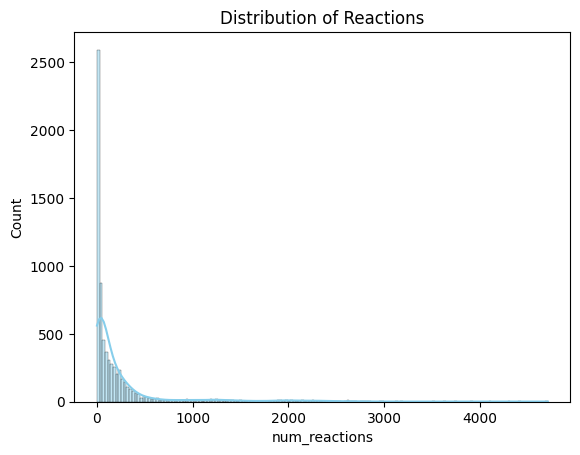

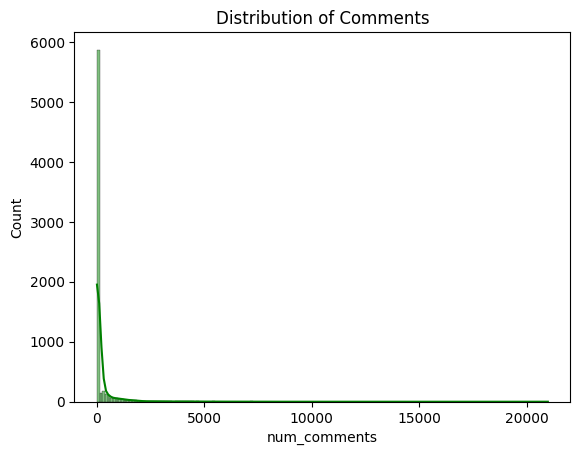

In [74]:
plt.figure(figsize=(10, 6))
plt.scatter(data['num_reactions'], data['num_comments'], alpha=.6, s=50)
plt.title("Engagement: Reactions vs Comments")
plt.grid(True, linestyle='--', alpha=.7)
plt.show()

# fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['num_reactions'], kde=True, color='skyblue')
plt.title('Distribution of Reactions')
plt.show()

sns.histplot(data['num_comments'], kde=True, color='green')
plt.title('Distribution of Comments')
plt.show()

In [75]:
kmeans = KMeans(n_clusters=4, random_state=37, n_init=10)
labels = kmeans.fit_predict(df_scaled_features)

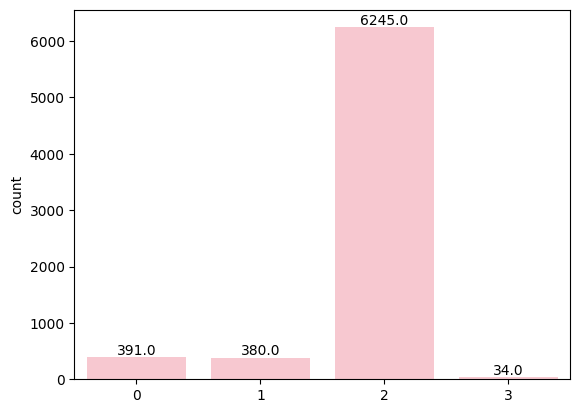

In [76]:
ax = sns.countplot(x=labels, color='pink')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom')
plt.show()

In [77]:
data['Cluster'] = labels
data.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Cluster
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,2
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,2
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,2
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,2
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,2


In [78]:
print(kmeans.cluster_centers_)

[[ 3.35246253 -0.18585645 -0.21874431  3.47126774 -0.24103078  0.13313017
  -0.12817995 -0.13336989 -0.14870982]
 [ 0.66662331  2.81444887  2.66829165  0.45158262  2.37303151  0.28855284
   1.18869387  1.3353606   1.65111707]
 [-0.26567285 -0.16876344 -0.17805157 -0.25539674 -0.16818993 -0.08874256
  -0.10332926 -0.08220069 -0.10397015]
 [ 2.79403685  1.67961793  5.39736106  1.94369348  7.14227048 11.54392086
   7.16782069  1.70746866  2.35337266]]


In [79]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers = pd.DataFrame(centers, columns=features.columns)
cluster_centers

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,1780.941176,59.023018,11.237852,1775.171355,3.094629,2.450128,0.189258,0.030691,0.005115
1,538.492105,2728.015789,391.144737,418.002632,107.578947,3.805263,5.400000,2.376316,1.313158
2,107.218895,74.228503,16.592634,100.257486,6.006085,0.515612,0.287590,0.112410,0.037630
3,1522.617647,1718.500000,750.264706,1088.617647,298.205882,101.941176,29.058824,2.970588,1.823529


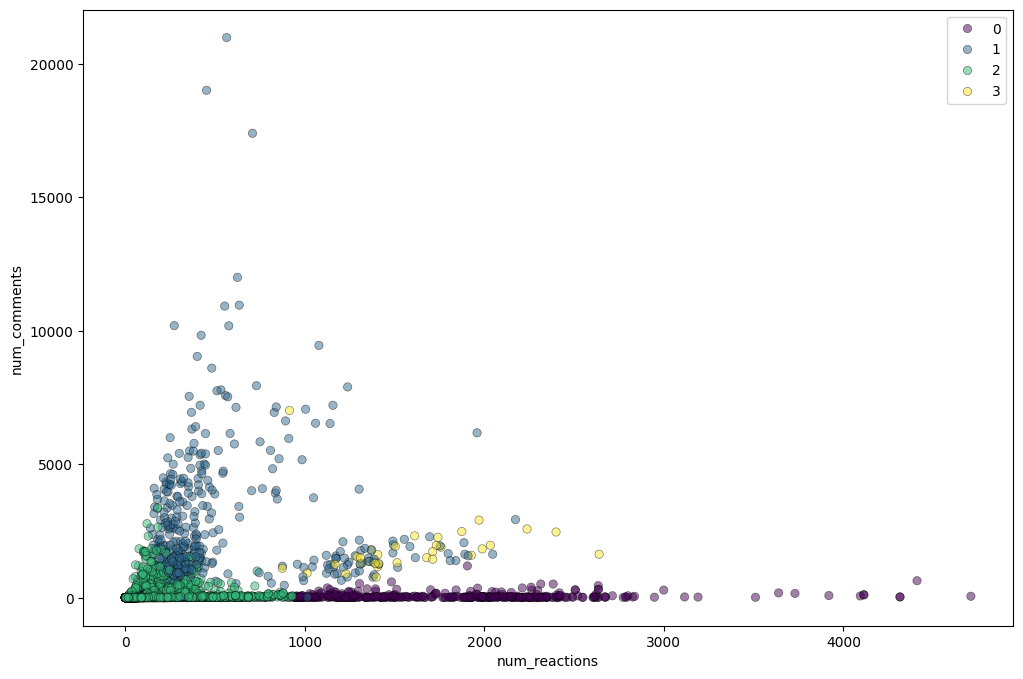

Text(0.5, 1.0, 'Comments by Cluster')

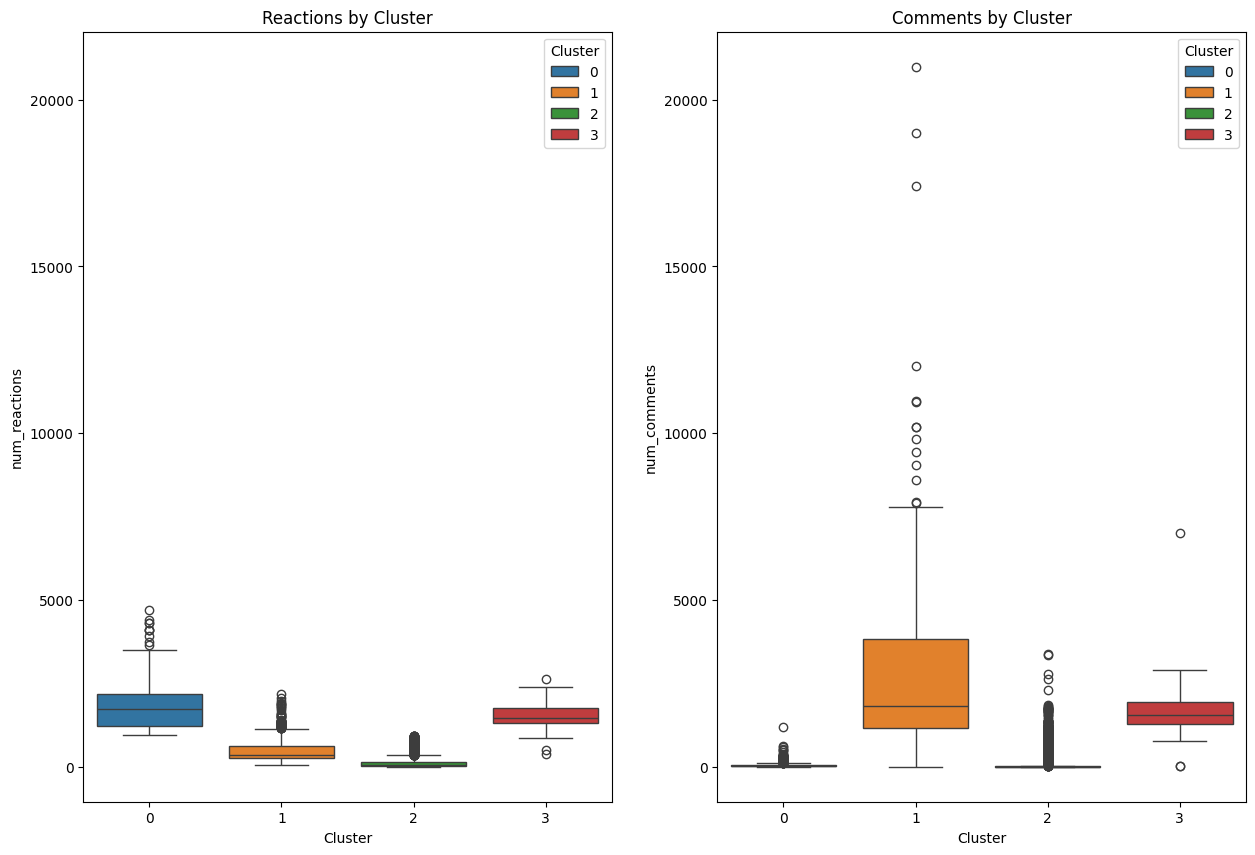

In [90]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=data, x='num_reactions', y='num_comments', hue='Cluster', palette='viridis',
               edgecolor='k', alpha=.5)
plt.legend()
plt.show()

plt.figure(figsize=(15, 10))

ax1 = plt.subplot(1,2,1)
sns.boxplot(data=data, y='num_reactions', x='Cluster', hue='Cluster', palette='tab10')
plt.title('Reactions by Cluster')

plt.subplot(1,2,2, sharey=ax1)
sns.boxplot(data=data, y='num_comments', x='Cluster', hue='Cluster', palette='tab10')
plt.title('Comments by Cluster')

### Elbow method and Silhouette Score

[0.8157664963358279, 0.7499921477403513, 0.7551693532879844, 0.760455937826355, 0.7140576613067617, 0.7118652447256547, 0.7136934383847656, 0.7097615583539857, 0.6894531680692848, 0.6941116402444143, 0.6945853646132975, 0.5861687374566086, 0.6827331418575388, 0.692142451147043]


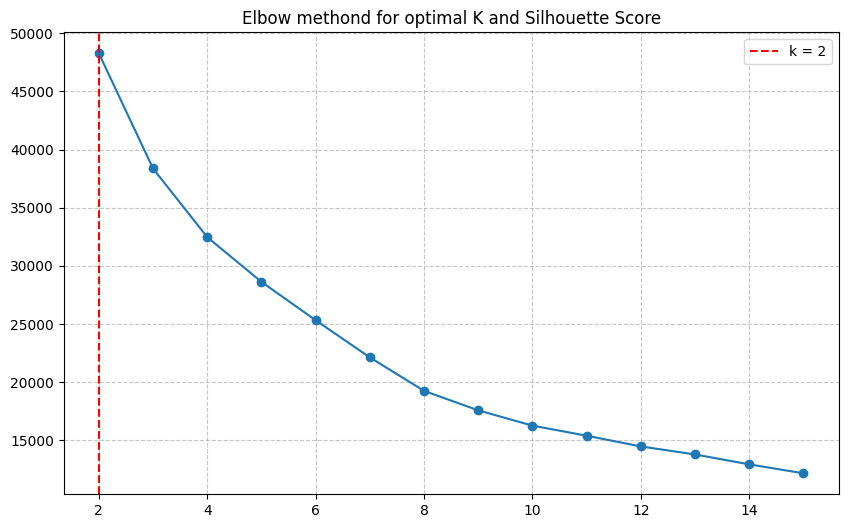

In [88]:
inertia = []
silhouette_scores = []
k_range = range(2, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=37, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, cluster_labels)
    silhouette_scores.append(score)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='-')


print(silhouette_scores)

best_k_silhouette = k_range[np.argmax(silhouette_scores)]
plt.axvline(x = best_k_silhouette, color='red', linestyle='--', 
            label=f'k = {best_k_silhouette}')

plt.title('Elbow methond for optimal K and Silhouette Score')
plt.grid(True, linestyle='--', alpha=.7)
plt.legend()
plt.show()